In [3]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

In [4]:
import sys
from pathlib import Path
_repo = Path.cwd().resolve()
for _ in range(12):
    if (_repo / "utils" / "data_paths.py").exists():
        sys.path.insert(0, str(_repo))
        break
    if _repo.parent == _repo:
        raise FileNotFoundError("Could not find utils/data_paths.py; run Jupyter from ml-notebook repo.")
    _repo = _repo.parent
from utils.data_paths import data_dir
DATA = data_dir()
df = pd.read_csv(DATA / "kickstarter_data_with_features.csv")
print(df.head())
print(df.info())


   Unnamed: 0          id                                              photo  \
0           0  1454391034  {"small":"https://ksr-ugc.imgix.net/assets/011...   
1           1  1655206086  {"small":"https://ksr-ugc.imgix.net/assets/012...   
2           2   311581827  {"small":"https://ksr-ugc.imgix.net/assets/012...   
3           3   859724515  {"small":"https://ksr-ugc.imgix.net/assets/011...   
4           4  1613604977  {"small":"https://ksr-ugc.imgix.net/assets/012...   

                                                name  \
0  Auntie Di's Music Time Sign ASL for Hearing an...   
1                    Jump Start Kindergarten Toolkit   
2  Ojukwu Balewa Awolowo (O.B.A.) Public Library ...   
3      MASTIZE - [mas-TAHYZ, MAS-tahyz]  - to spread   
4  Synopse der EU-DSGVO - Artikel, Erwägungsgründ...   

                                               blurb      goal  pledged  \
0  MTS ASL Curriculum Workbook is a reproducible ...    1500.0      0.0   
1  This kit teaches how to print

/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_3936/1560269636.py:1: DtypeWarning: Columns (29,30,31,32) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/kickstarter_data_with_features.csv")


In [5]:
df = df[df['state'].isin(['successful', 'failed'])]

# Convert target variable to binary (1 for success, 0 for failure)
df['state'] = df['state'].map({'successful': 1, 'failed': 0})

In [6]:
from sklearn.preprocessing import LabelEncoder

cat_features = ['category', 'currency', 'country']
for col in cat_features:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [7]:
X = df[['category', 'goal', 'country']]
y = df['state']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [55]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    objective="binary",
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    n_estimators=100,
    metric='auc'
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)])


[LightGBM] [Info] Number of positive: 4841, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000095 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 13947, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347100 -> initscore=-0.631812
[LightGBM] [Info] Start training from score -0.631812


LGBMClassifier(learning_rate=0.05, metric='auc', objective='binary')

In [56]:
y_pred = model.predict(X_test)
y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print("Classification Report:\n", classification_report(y_test, y_pred_binary))


Accuracy: 0.7166618870088901
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.86      0.80      2310
           1       0.61      0.43      0.51      1177

    accuracy                           0.72      3487
   macro avg       0.68      0.65      0.65      3487
weighted avg       0.70      0.72      0.70      3487



In [57]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc_score:.4f}")

AUC-ROC Score: 0.7631


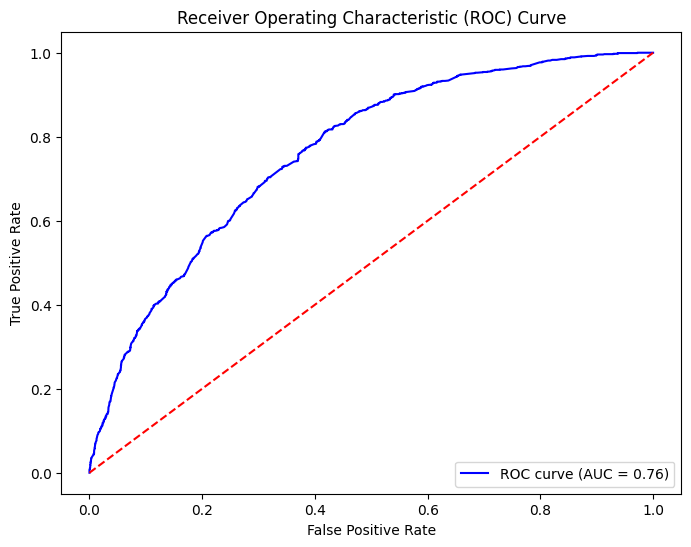

In [58]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [59]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [60]:
model.fit(X_train_resampled, y_train_resampled, eval_set=[(X_test, y_test)])

[LightGBM] [Info] Number of positive: 9106, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000171 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 290
[LightGBM] [Info] Number of data points in the train set: 18212, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


LGBMClassifier(learning_rate=0.05, metric='auc', objective='binary')

In [61]:
y_pred = model.predict(X_test)
y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print("Classification Report:\n", classification_report(y_test, y_pred_binary))

Accuracy: 0.647834815027244
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.59      0.69      2310
           1       0.49      0.77      0.60      1177

    accuracy                           0.65      3487
   macro avg       0.66      0.68      0.64      3487
weighted avg       0.72      0.65      0.66      3487



In [62]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc_score:.4f}")

AUC-ROC Score: 0.7547


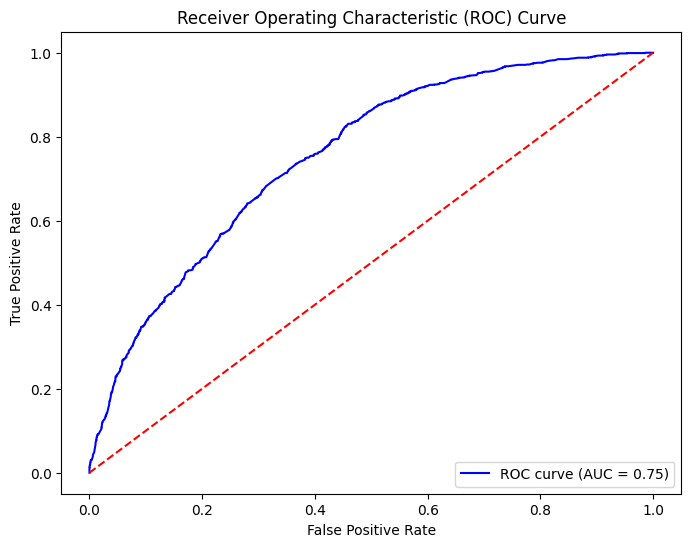

In [63]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_prob = model.predict_proba(X_test)[:, 1]  

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [64]:
model = LGBMClassifier(
    objective="binary",
    learning_rate=0.03,
    num_leaves=50, # Increase leaf count for better separation
    max_depth=-1,
    n_estimators=100,
    metric='auc',
    boosting_type='gbdt',
    min_data_in_leaf=20,  # Reduce minimum samples per leaf
    scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),  # Balance classes
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] Number of positive: 4841, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000107 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 289
[LightGBM] [Info] Number of data points in the train set: 13947, number of used features: 3
[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.347100 -> initscore=-0.631812
[LightGBM] [Info] Start training from score -0.631812


LGBMClassifier(learning_rate=0.03, metric='auc', min_data_in_leaf=20,
               num_leaves=50, objective='binary', random_state=42,
               scale_pos_weight=1.8810163189423672)

In [65]:
y_pred = model.predict(X_test)
y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print("Classification Report:\n", classification_report(y_test, y_pred_binary))

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
Accuracy: 0.6722110696874104
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.63      0.72      2310
           1       0.51      0.76      0.61      1177

    accuracy                           0.67      3487
   macro avg       0.67      0.69      0.66      3487
weighted avg       0.73      0.67      0.68      3487



In [66]:
from sklearn.metrics import roc_auc_score

# Get predicted probabilities
y_pred_prob = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc_score:.4f}")

[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20
AUC-ROC Score: 0.7626


[LightGBM] [Warning] min_data_in_leaf is set=20, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=20


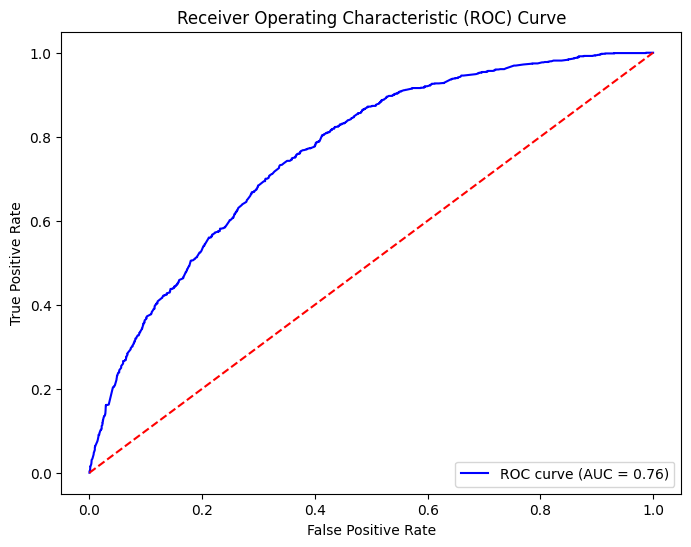

In [67]:
y_pred_prob = model.predict_proba(X_test)[:, 1]  

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Instead of guessing, let's use Optuna to automate finding the best hyperparameters

In [68]:
import optuna
import lightgbm as lgb
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split

def objective(trial):
    params = {
        'objective': 'binary',
        'metric': 'auc',
        'boosting_type': 'gbdt',
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 10, 100),
        'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-3, 10.0),
        'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-3, 10.0),
        'scale_pos_weight': sum(y_train == 0) / sum(y_train == 1),  # Balance classes
        'random_state': 42
    }

    model = lgb.LGBMClassifier(**params)
    model.fit(X_train, y_train, eval_set=[(X_test, y_test)])
    preds = model.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

best_params = study.best_params
print("Best Hyperparameters:", best_params)

[I 2025-02-26 02:23:49,106] A new study created in memory with name: no-name-c90f7afc-d29f-4713-825b-1a2c6a4d1f14


[LightGBM] [Warning] lambda_l1 is set=1.157060875356671, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.157060875356671
[LightGBM] [Warning] lambda_l2 is set=0.5282752974245017, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5282752974245017
[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Warning] lambda_l1 is set=1.157060875356671, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.157060875356671
[LightGBM] [Warning] lambda_l2 is set=0.5282752974245017, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.5282752974245017
[LightGBM] [Warning] min_data_in_leaf is set=86, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=86
[LightGBM] [Info] Number of positive: 4841, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000124 seconds.
You can set `force_row_wise=true` to remove the overh

/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_8529/3424390460.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_8529/3424390460.py:15: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-3, 10.0),
/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_8529/3424390460.py:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-02-26 02:23:49,353] Trial 0 finished with value: 0.7506153291624829 and parameters: {'learning_rate': 0.01778608716460056, 'num_leaves': 86, 'max_depth': 7, 'min_data_in_leaf': 86, 'lambda_l1': 1.157060875356671, 'lambda_l2': 0.5282752974245017}. Best is trial 0 with value: 0.7506153291624829.


...

[LightGBM] [Warning] lambda_l1 is set=2.0388218751841545, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0388218751841545
[LightGBM] [Warning] lambda_l2 is set=0.8485298807126084, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.8485298807126084
[LightGBM] [Warning] min_data_in_leaf is set=11, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=11
[LightGBM] [Warning] lambda_l1 is set=2.0388218751841545, reg_alpha=0.0 will be ignored. Current value: lambda_l1=2.0388218751841545
[LightGBM] [Warning] lambda_l2 is set=0.8485298807126084, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.8485298807126084
[LightGBM] [Warning] min_data_in_leaf is set=11, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=11
[LightGBM] [Info] Number of positive: 4841, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000068 seconds.
You can set `force_row_wise=true` to remove the o

[I 2025-02-26 02:23:58,059] Trial 48 finished with value: 0.7644602353183492 and parameters: {'learning_rate': 0.12915194830021112, 'num_leaves': 54, 'max_depth': 9, 'min_data_in_leaf': 13, 'lambda_l1': 1.2680812023534118, 'lambda_l2': 0.8533696332301903}. Best is trial 43 with value: 0.766545844413304.
/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_8529/3424390460.py:11: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_8529/3424390460.py:15: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-3, 10.0),
/var/folders/th/55hfqgh912325b89wjzp3d_w0000gn/T/ipykernel_8529/3424390460.py:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-3, 10.0),
[I 2025-02-26 02:23:58,312] Trial 49 finished with value: 0.7644677752154387 and parameters: {'learning_rate': 0.1401663111652645, 'num_leaves': 53, 'max_depth': 11, 'min_data_in_leaf': 10, 'lambda_l1': 5.414642184340784, 'lambda_l2': 3.605501273163301}. Best is trial 43 with value: 0.76654584

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[LightGBM] [Warning] lambda_l1 is set=0.7222963845184093, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7222963845184093
[LightGBM] [Warning] lambda_l2 is set=0.010573392384966162, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.010573392384966162
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Warning] lambda_l1 is set=0.7222963845184093, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7222963845184093
[LightGBM] [Warning] lambda_l2 is set=0.010573392384966162, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.010573392384966162
[LightGBM] [Warning] min_data_in_leaf is set=10, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=10
[LightGBM] [Info] Number of positive: 4841, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000108 seconds.
You can set `force_row_wise=true` to remo

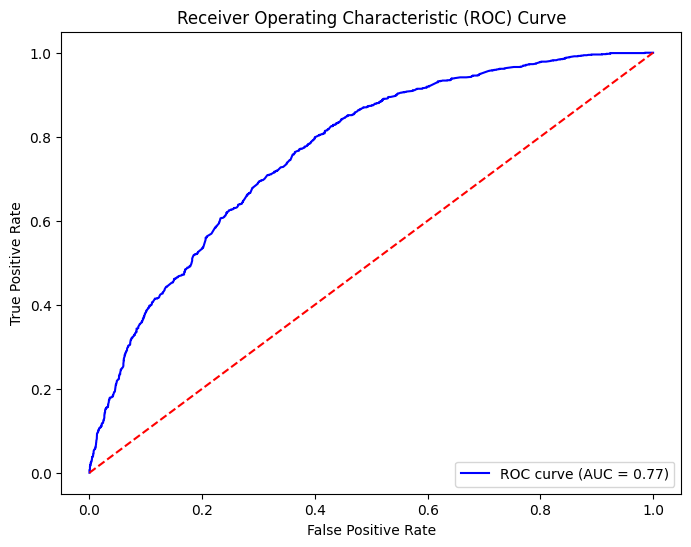

In [ ]:
model = LGBMClassifier(
    objective="binary",
    learning_rate=0.08579634474190347,
    num_leaves=71, # Increase leaf count for better separation
    max_depth=11,
    lambda_l1= 0.7222963845184093,
    lambda_l2= 0.010573392384966162,
  #  n_estimators=100,
    metric='auc',
  #  boosting_type='gbdt',
    min_data_in_leaf=10,  # Reduce minimum samples per leaf
   # scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),  # Balance classes
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

y_pred = model.predict(X_test)
y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print("Classification Report:\n", classification_report(y_test, y_pred_binary))

from sklearn.metrics import roc_auc_score

y_pred_prob = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc_score:.4f}")

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [8]:
from lightgbm import LGBMClassifier

model = LGBMClassifier(
    objective="binary",
    learning_rate=0.09720011946650364,
    num_leaves=53, # Increase leaf count for better separation
    max_depth=9,
    lambda_l1= 1.7926372080648554,
    lambda_l2= 0.07404762089587796,
  #  n_estimators=100,
    metric='auc',
  #  boosting_type='gbdt',
    min_data_in_leaf=13,  # Reduce minimum samples per leaf
   # scale_pos_weight=sum(y_train == 0) / sum(y_train == 1),  # Balance classes
    random_state=42
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)])

y_pred = model.predict(X_test)
y_pred_binary = [1 if pred > 0.5 else 0 for pred in y_pred]

print("Accuracy:", accuracy_score(y_test, y_pred_binary))
print("Classification Report:\n", classification_report(y_test, y_pred_binary))

from sklearn.metrics import roc_auc_score

y_pred_prob = model.predict_proba(X_test)[:, 1]  

auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC-ROC Score: {auc_score:.4f}")

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Random guessing line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

[LightGBM] [Warning] lambda_l1 is set=1.7926372080648554, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.7926372080648554
[LightGBM] [Warning] lambda_l2 is set=0.07404762089587796, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.07404762089587796
[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Warning] lambda_l1 is set=1.7926372080648554, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.7926372080648554
[LightGBM] [Warning] lambda_l2 is set=0.07404762089587796, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.07404762089587796
[LightGBM] [Warning] min_data_in_leaf is set=13, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=13
[LightGBM] [Info] Number of positive: 4841, number of negative: 9106
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000316 seconds.
You can set `force_row_wise=true` to remove t

NameError: name 'roc_curve' is not defined